<a href="https://colab.research.google.com/github/abdullahalmusabbir/Deep-Learning-Project/blob/main/Classification_of_Arrhythmia.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [207]:
import pandas as pd
import numpy as np
import scipy as sp
import math as mt
import seaborn as sns

import matplotlib.pyplot as plt
#to avoid writing plot.show
%matplotlib inline
from sklearn.impute import SimpleImputer

In [208]:
df=pd.read_csv("arrhythmia1.csv")

In [209]:
df.head()

,75,0,190,80,91,193,371,174,121,-16,...,0.0.38,9.0,-0.9,0.0.39,0.0.40,0.9.2,2.9.1,23.3,49.4,8
0,56,1,165,64,81,174,401,149,39,25,...,0.0,8.5,0.0,0.0,0.0,0.2,2.1,20.4,38.8,6
1,54,0,172,95,138,163,386,185,102,96,...,0.0,9.5,-2.4,0.0,0.0,0.3,3.4,12.3,49.0,10
2,55,0,175,94,100,202,380,179,143,28,...,0.0,12.2,-2.2,0.0,0.0,0.4,2.6,34.6,61.6,1
3,75,0,190,80,88,181,360,177,103,-16,...,0.0,13.1,-3.6,0.0,0.0,-0.1,3.9,25.4,62.8,7
4,13,0,169,51,100,167,321,174,91,107,...,-0.6,12.2,-2.8,0.0,0.0,0.9,2.2,13.5,31.1,14


In [210]:
df.tail()

,75,0,190,80,91,193,371,174,121,-16,...,0.0.38,9.0,-0.9,0.0.39,0.0.40,0.9.2,2.9.1,23.3,49.4,8
446,53,1,160,70,80,199,382,154,117,-37,...,0.0,4.3,-5.0,0.0,0.0,0.7,0.6,-4.4,-0.5,1
447,37,0,190,85,100,137,361,201,73,86,...,0.0,15.6,-1.6,0.0,0.0,0.4,2.4,38.0,62.4,10
448,36,0,166,68,108,176,365,194,116,-85,...,0.0,16.3,-28.6,0.0,0.0,1.5,1.0,-44.2,-33.2,2
449,32,1,155,55,93,106,386,218,63,54,...,-0.4,12.0,-0.7,0.0,0.0,0.5,2.4,25.0,46.6,1
450,78,1,160,70,79,127,364,138,78,28,...,0.0,10.4,-1.8,0.0,0.0,0.5,1.6,21.3,32.8,1


# **Basic Description of dataframe**

In [211]:
df.shape

(451, 280)

In [212]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 451 entries, 0 to 450
Columns: 280 entries, 75 to 8
dtypes: float64(120), int64(155), object(5)
memory usage: 986.7+ KB


In [213]:
df.describe()

,75,0,190,80,91,193,371,174,121,-16,...,0.0.38,9.0,-0.9,0.0.39,0.0.40,0.9.2,2.9.1,23.3,49.4,8
count,451.000000,451.000000,451.000000,451.000000,451.000000,451.000000,451.000000,451.000000,451.000000,451.000000,...,451.000000,451.000000,451.000000,451.000000,451.0,451.000000,451.000000,451.000000,451.000000,451.000000
mean,46.407982,0.552106,166.135255,68.144124,88.915743,155.068736,367.199557,169.940133,89.935698,33.787140,...,-0.279601,9.048115,-1.458537,0.003991,0.0,0.513969,1.218625,19.317295,29.429047,3.871397
std,16.429846,0.497830,37.194646,16.599841,15.381143,44.856534,33.422017,35.672130,25.813912,45.421423,...,0.549328,3.476718,2.004481,0.050173,0.0,0.347441,1.425438,13.517617,18.490566,4.407706
min,0.000000,0.000000,105.000000,6.000000,55.000000,0.000000,232.000000,108.000000,0.000000,-172.000000,...,-4.100000,0.000000,-28.600000,0.000000,0.0,-0.800000,-6.000000,-44.200000,-38.600000,1.000000
25%,36.000000,0.000000,160.000000,59.000000,80.000000,142.000000,350.000000,148.000000,79.000000,4.000000,...,-0.450000,6.600000,-2.100000,0.000000,0.0,0.400000,0.500000,11.400000,17.500000,1.000000
50%,47.000000,1.000000,164.000000,68.000000,86.000000,157.000000,367.000000,162.000000,91.000000,40.000000,...,0.000000,8.800000,-1.100000,0.000000,0.0,0.500000,1.300000,18.100000,27.900000,1.000000
75%,58.000000,1.000000,170.000000,78.500000,94.000000,174.500000,384.000000,179.000000,102.000000,66.000000,...,0.000000,11.200000,0.000000,0.000000,0.0,0.700000,2.100000,25.850000,41.050000,6.000000
max,83.000000,1.000000,780.000000,176.000000,188.000000,524.000000,509.000000,381.000000,205.000000,169.000000,...,0.000000,23.600000,0.000000,0.800000,0.0,2.400000,6.000000,88.800000,115.900000,16.000000


# **1. Data preprocessing**

**Handling Missing Values**

In [214]:
pd.isnull(df).sum()

,0
75,0
0,0
190,0
80,0
91,0
...,...
0.9.2,0
2.9.1,0
23.3,0
49.4,0


In [215]:
df = df.replace('?', np.nan)

In [216]:
nv=pd.isnull(df).sum().sum()
nv

np.int64(407)

**Visualizing the distribution of our missing data:**

Text(0, 0.5, 'Total number of null value in each column')

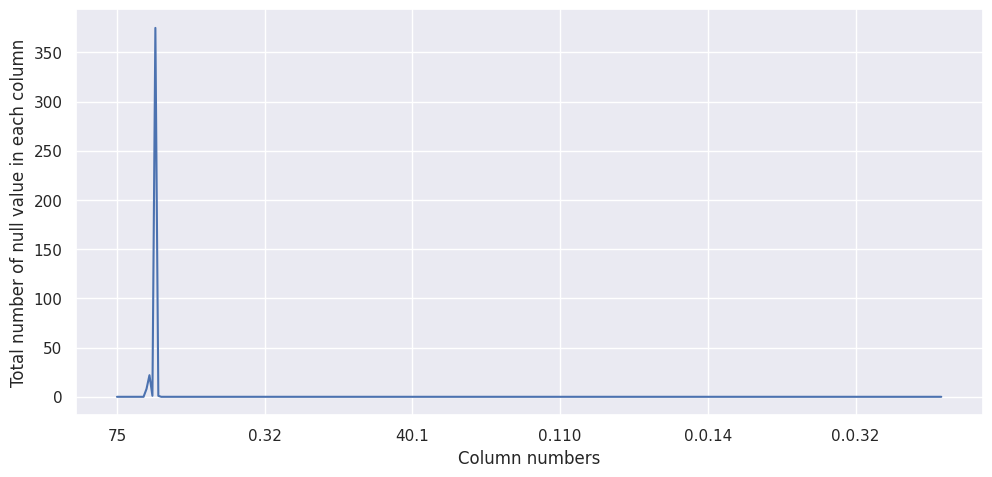

In [217]:
pd.isnull(df).sum().plot()
plt.xlabel('Column numbers')
plt.ylabel('Total number of null value in each column')

Text(0, 0.5, 'Total number of null value in each column')

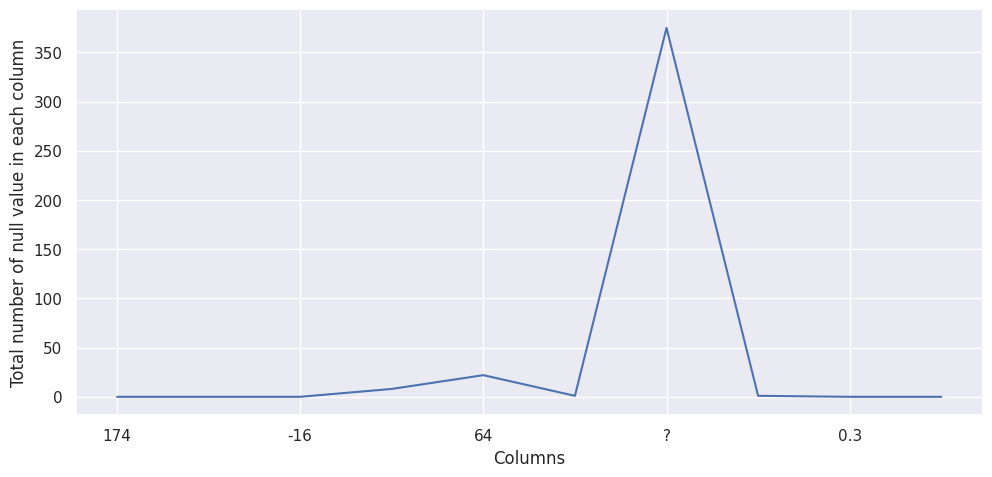

In [218]:
pd.isnull(df).sum()[7:17].plot(kind="line")
plt.xlabel('Columns')
plt.ylabel('Total number of null value in each column')

In [219]:
df.dtypes

,0
75,int64
0,int64
190,int64
80,int64
91,int64
...,...
0.9.2,float64
2.9.1,float64
23.3,float64
49.4,float64


In [220]:
df.drop(df.columns[13], axis=1, inplace=True)

In [221]:
new_df = df.copy()

In [222]:
cols_with_missing = (col for col in new_df.columns if new_df[col].isnull().any())
for col in cols_with_missing:
    new_df[col] = new_df[col].isnull()

In [223]:
my_imputer = SimpleImputer()
new_df = pd.DataFrame(my_imputer.fit_transform(new_df))
new_df.columns = df.columns

In [224]:
new_df.head()

,75,0,190,80,91,193,371,174,121,-16,...,0.0.38,9.0,-0.9,0.0.39,0.0.40,0.9.2,2.9.1,23.3,49.4,8
0,56.0,1.0,165.0,64.0,81.0,174.0,401.0,149.0,39.0,25.0,...,0.0,8.5,0.0,0.0,0.0,0.2,2.1,20.4,38.8,6.0
1,54.0,0.0,172.0,95.0,138.0,163.0,386.0,185.0,102.0,96.0,...,0.0,9.5,-2.4,0.0,0.0,0.3,3.4,12.3,49.0,10.0
2,55.0,0.0,175.0,94.0,100.0,202.0,380.0,179.0,143.0,28.0,...,0.0,12.2,-2.2,0.0,0.0,0.4,2.6,34.6,61.6,1.0
3,75.0,0.0,190.0,80.0,88.0,181.0,360.0,177.0,103.0,-16.0,...,0.0,13.1,-3.6,0.0,0.0,-0.1,3.9,25.4,62.8,7.0
4,13.0,0.0,169.0,51.0,100.0,167.0,321.0,174.0,91.0,107.0,...,-0.6,12.2,-2.8,0.0,0.0,0.9,2.2,13.5,31.1,14.0


In [225]:
pd.isnull(new_df).sum()

,0
75,0
0,0
190,0
80,0
91,0
...,...
0.9.2,0
2.9.1,0
23.3,0
49.4,0


In [226]:
final_df_columns=["Age","Sex","Height","Weight","QRS_Dur",
"P-R_Int","Q-T_Int","T_Int","P_Int","QRS","T","P","J","Heart_Rate",
"Q_Wave","R_Wave","S_Wave","R'_Wave","S'_Wave","Int_Def","Rag_R_Nom",
"Diph_R_Nom","Rag_P_Nom","Diph_P_Nom","Rag_T_Nom","Diph_T_Nom",
"DII00", "DII01","DII02", "DII03", "DII04","DII05","DII06","DII07","DII08","DII09","DII10","DII11",
"DIII00","DIII01","DIII02", "DIII03", "DIII04","DIII05","DIII06","DIII07","DIII08","DIII09","DIII10","DIII11",
"AVR00","AVR01","AVR02","AVR03","AVR04","AVR05","AVR06","AVR07","AVR08","AVR09","AVR10","AVR11",
"AVL00","AVL01","AVL02","AVL03","AVL04","AVL05","AVL06","AVL07","AVL08","AVL09","AVL10","AVL11",
"AVF00","AVF01","AVF02","AVF03","AVF04","AVF05","AVF06","AVF07","AVF08","AVF09","AVF10","AVF11",
"V100","V101","V102","V103","V104","V105","V106","V107","V108","V109","V110","V111",
"V200","V201","V202","V203","V204","V205","V206","V207","V208","V209","V210","V211",
"V300","V301","V302","V303","V304","V305","V306","V307","V308","V309","V310","V311",
"V400","V401","V402","V403","V404","V405","V406","V407","V408","V409","V410","V411",
"V500","V501","V502","V503","V504","V505","V506","V507","V508","V509","V510","V511",
"V600","V601","V602","V603","V604","V605","V606","V607","V608","V609","V610","V611",
"JJ_Wave","Amp_Q_Wave","Amp_R_Wave","Amp_S_Wave","R_Prime_Wave","S_Prime_Wave","P_Wave","T_Wave",
"QRSA","QRSTA","DII170","DII171","DII172","DII173","DII174","DII175","DII176","DII177","DII178","DII179",
"DIII180","DIII181","DIII182","DIII183","DIII184","DIII185","DIII186","DIII187","DIII188","DIII189",
"AVR190","AVR191","AVR192","AVR193","AVR194","AVR195","AVR196","AVR197","AVR198","AVR199",
"AVL200","AVL201","AVL202","AVL203","AVL204","AVL205","AVL206","AVL207","AVL208","AVL209",
"AVF210","AVF211","AVF212","AVF213","AVF214","AVF215","AVF216","AVF217","AVF218","AVF219",
"V1220","V1221","V1222","V1223","V1224","V1225","V1226","V1227","V1228","V1229",
"V2230","V2231","V2232","V2233","V2234","V2235","V2236","V2237","V2238","V2239",
"V3240","V3241","V3242","V3243","V3244","V3245","V3246","V3247","V3248","V3249",
"V4250","V4251","V4252","V4253","V4254","V4255","V4256","V4257","V4258","V4259",
"V5260","V5261","V5262","V5263","V5264","V5265","V5266","V5267","V5268","V5269",
"V6270","V6271","V6272","V6273","V6274","V6275","V6276","V6277","V6278","V6279","class"]

In [227]:
new_df.columns=final_df_columns
new_df.to_csv("new data with target class.csv")
new_df.head()

,Age,Sex,Height,Weight,QRS_Dur,P-R_Int,Q-T_Int,T_Int,P_Int,QRS,...,V6271,V6272,V6273,V6274,V6275,V6276,V6277,V6278,V6279,class
0,56.0,1.0,165.0,64.0,81.0,174.0,401.0,149.0,39.0,25.0,...,0.0,8.5,0.0,0.0,0.0,0.2,2.1,20.4,38.8,6.0
1,54.0,0.0,172.0,95.0,138.0,163.0,386.0,185.0,102.0,96.0,...,0.0,9.5,-2.4,0.0,0.0,0.3,3.4,12.3,49.0,10.0
2,55.0,0.0,175.0,94.0,100.0,202.0,380.0,179.0,143.0,28.0,...,0.0,12.2,-2.2,0.0,0.0,0.4,2.6,34.6,61.6,1.0
3,75.0,0.0,190.0,80.0,88.0,181.0,360.0,177.0,103.0,-16.0,...,0.0,13.1,-3.6,0.0,0.0,-0.1,3.9,25.4,62.8,7.0
4,13.0,0.0,169.0,51.0,100.0,167.0,321.0,174.0,91.0,107.0,...,-0.6,12.2,-2.8,0.0,0.0,0.9,2.2,13.5,31.1,14.0


In [228]:
target=new_df["class"]

final_df = new_df.drop(columns ="class")

In [229]:
final_df.shape

(451, 278)

# **2. Exploratory Data Analysis (EDA)**

In [230]:
class_names = ["Normal",
               "Ischemic changes (CAD)",
               "Old Anterior Myocardial Infraction",
               "Old Inferior Myocardial Infraction",
               "Sinus tachycardy",
               "Sinus bradycardy",
               "Ventricular Premature Contraction (PVC)",
               "Supraventricular Premature Contraction",
               "Left Boundle branch block",
               "Right boundle branch block",
               "1.Degree AtrioVentricular block",
               "2.Degree AV block",
               "3.Degree AV block",
               "Left Ventricule hypertrophy",
               "Atrial Fibrillation or Flutter",
               "Others"]

**Analyzing the dataset and check how many examples we have for each class:**

In [231]:
t=new_df.sort_values(by=["class"])

In [232]:
la = t["class"].value_counts(sort=False).tolist()
la

[245, 44, 15, 15, 13, 25, 3, 1, 9, 50, 4, 5, 22]

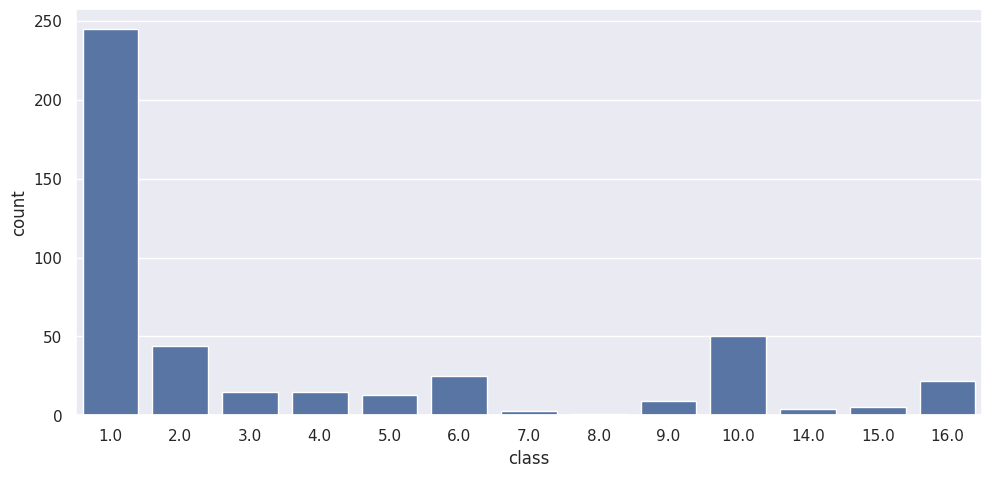

In [233]:
sns.countplot(x ='class',data =new_df)
plt.show()

In [234]:
values = la[0:10]
values.extend([0,0,0])
values.extend(la[10:13])
print(values)

[245, 44, 15, 15, 13, 25, 3, 1, 9, 50, 0, 0, 0, 4, 5, 22]


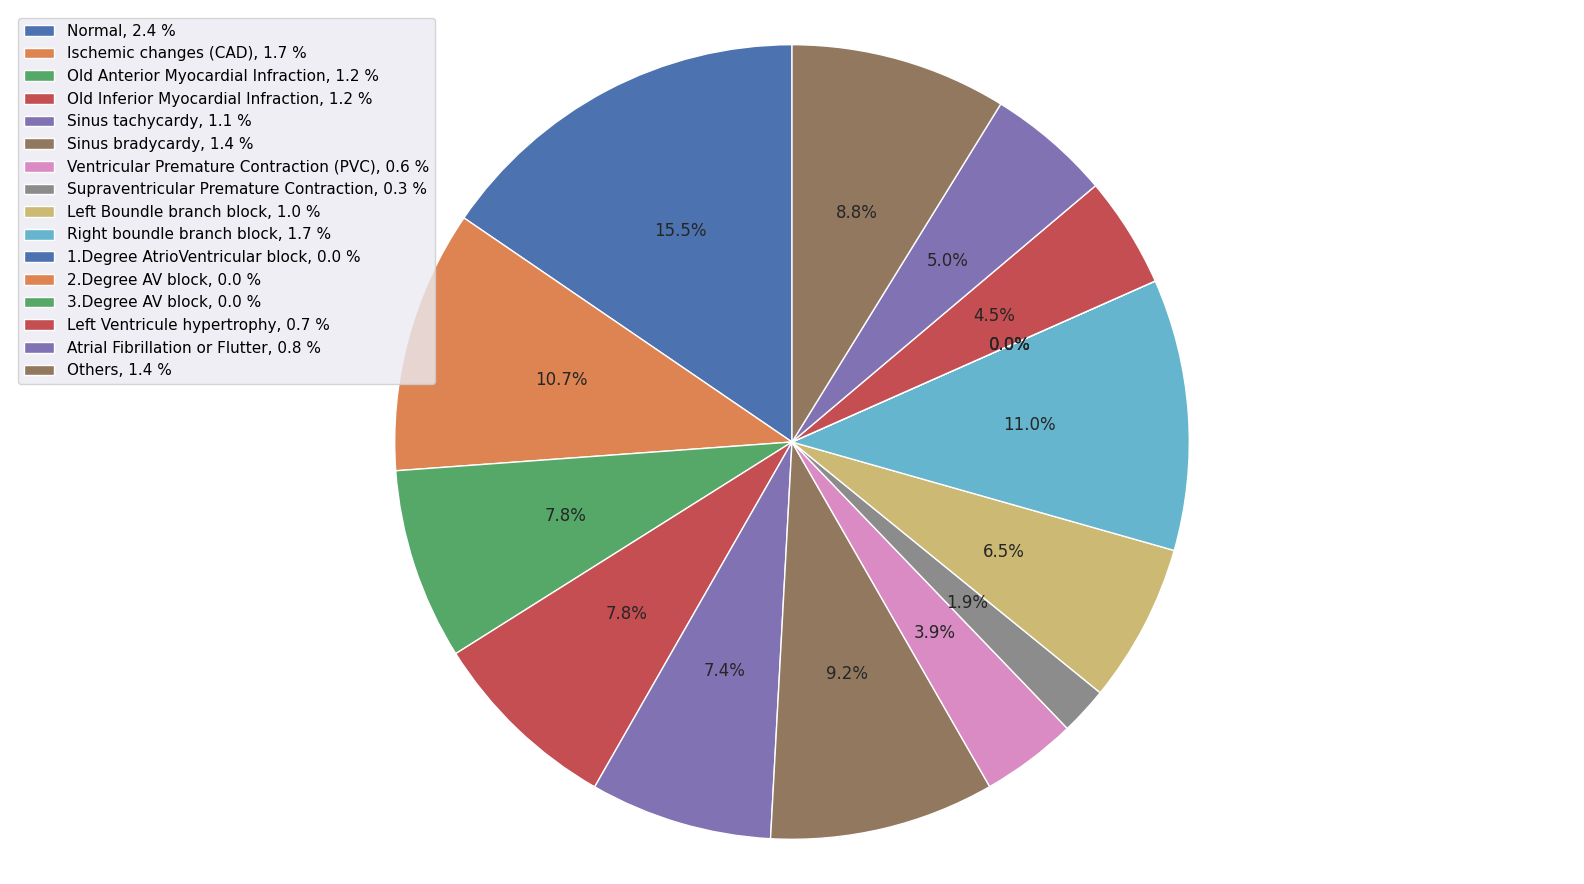

In [235]:
labels = class_names
Log_Norm = []
for i in values:
    Log_Norm.append(mt.log10(i+1))
fig1, ax1 = plt.subplots(figsize=(16,9))
patches = plt.pie(Log_Norm, autopct='%1.1f%%', startangle=90)

leg = plt.legend( loc = 'best', labels=['%s, %1.1f %%' % (l, s) for l, s in zip(labels, Log_Norm)])
plt.axis('equal')

for text in leg.get_texts():
    plt.setp(text, color = 'Black')
plt.tight_layout()
plt.show()

**Handling Outliers & Data Visualization**

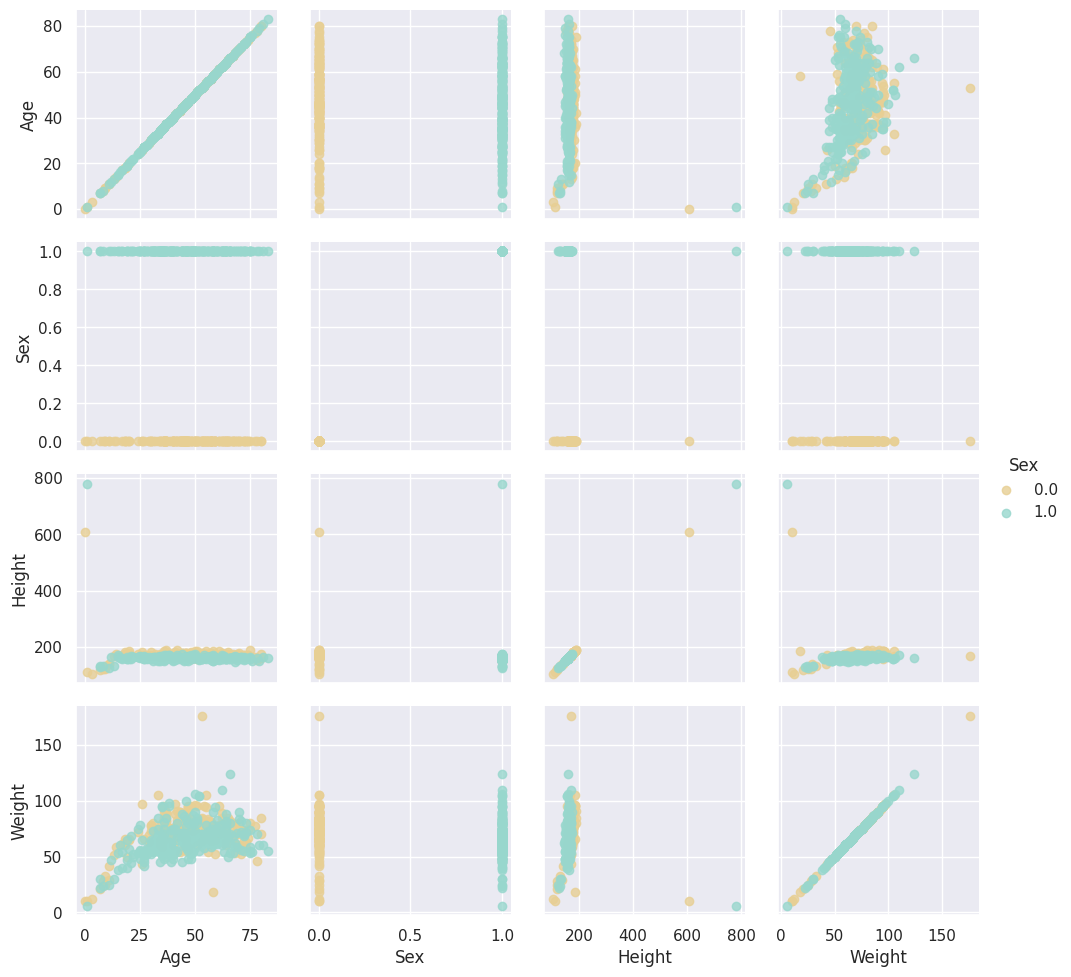

In [236]:
g = sns.PairGrid(final_df, vars=['Age', 'Sex', 'Height', 'Weight'],hue='Sex', palette='BrBG')
g.map(plt.scatter, alpha=0.8)
g.add_legend();

In [237]:
sorted(final_df['Height'], reverse=True)[:10]

[780.0, 608.0, 190.0, 190.0, 188.0, 186.0, 186.0, 186.0, 185.0, 185.0]

In [238]:
final_df['Height']=final_df['Height'].replace(608,108)
final_df['Height']=final_df['Height'].replace(780,180)

In [239]:
sorted(final_df['Weight'], reverse=True)[:10]

[176.0, 124.0, 110.0, 106.0, 105.0, 105.0, 104.0, 104.0, 100.0, 98.0]

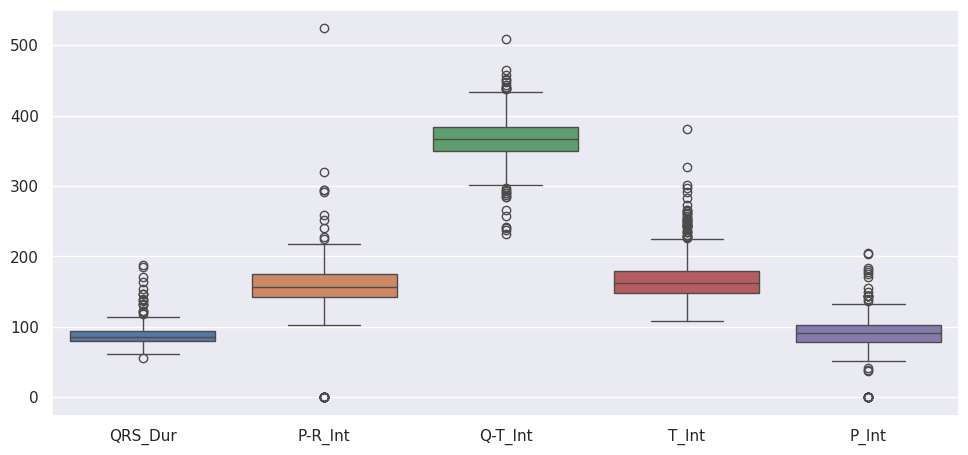

In [240]:
sns.boxplot(data=final_df[["QRS_Dur","P-R_Int","Q-T_Int","T_Int","P_Int"]]);

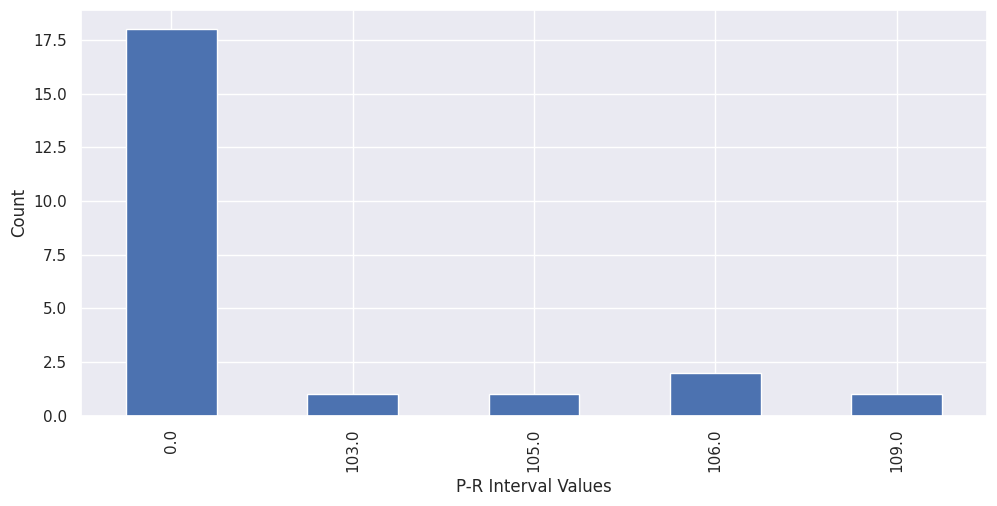

In [241]:
final_df['P-R_Int'].value_counts().sort_index().head().plot(kind='bar')
plt.xlabel('P-R Interval Values')
plt.ylabel('Count');

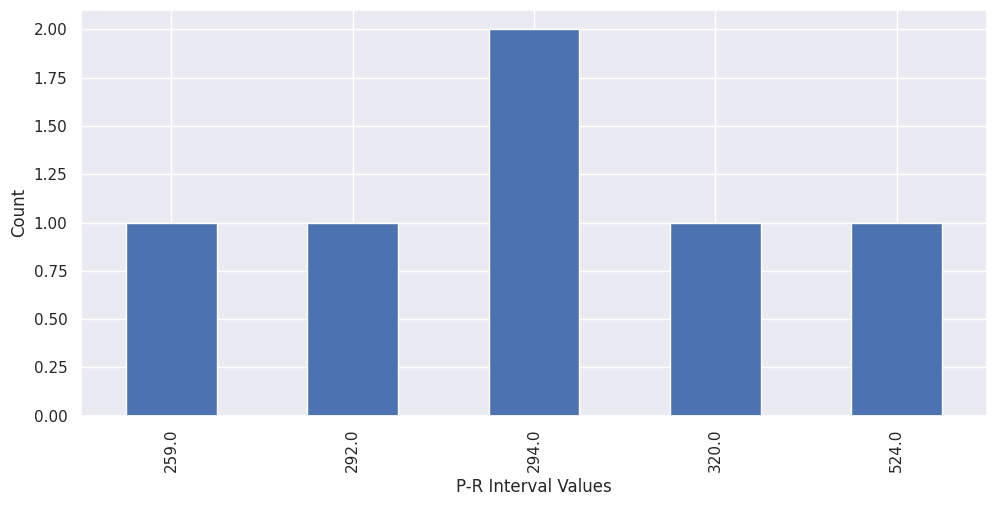

In [242]:
final_df['P-R_Int'].value_counts().sort_index().tail().plot(kind='bar')
plt.xlabel('P-R Interval Values')
plt.ylabel('Count');

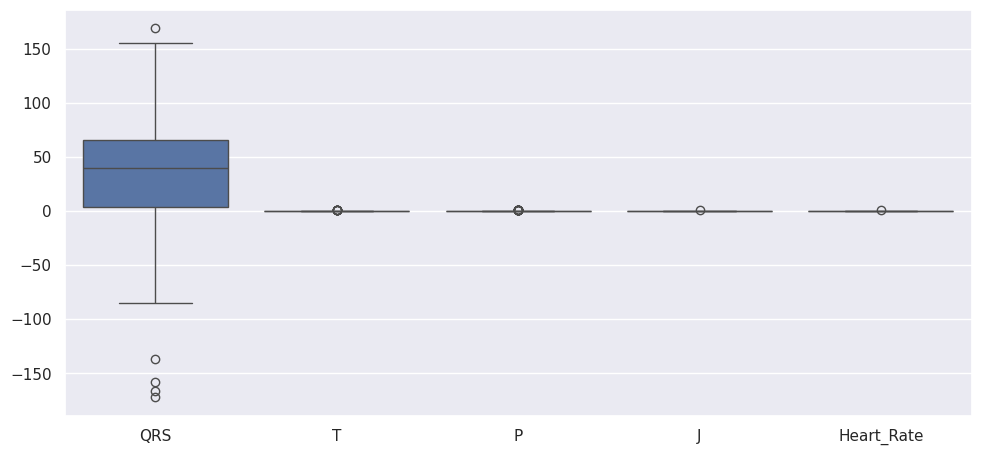

In [243]:
sns.boxplot(data=final_df[["QRS","T","P","J","Heart_Rate"]]);

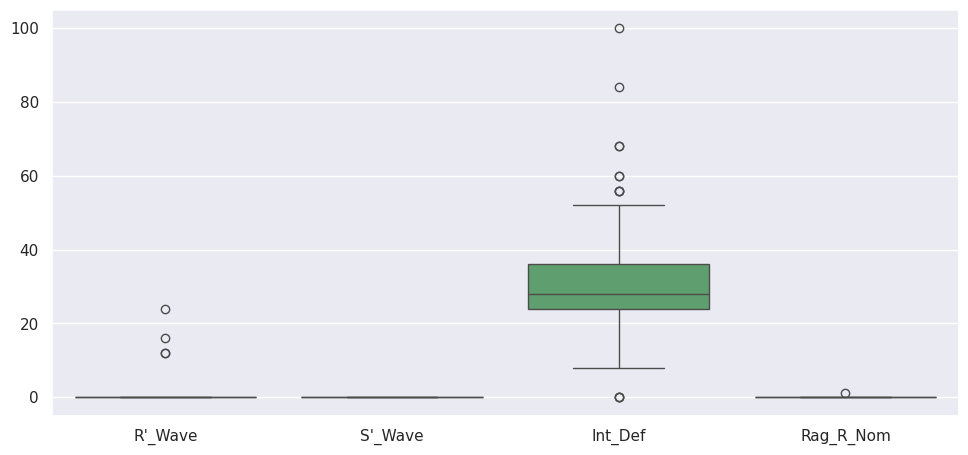

In [244]:
sns.boxplot(data=final_df[["R'_Wave","S'_Wave","Int_Def","Rag_R_Nom"]]);

In [245]:
final_df["S'_Wave"].value_counts().sort_index(ascending=False)

,count
S'_Wave,
0.0,451


In [246]:
final_df["V101"].value_counts().sort_index(ascending=False)

,count
V101,
216.0,1
112.0,1
84.0,1
72.0,1
68.0,1
64.0,1
48.0,6
44.0,6
40.0,13


In [247]:
final_df["V201"].value_counts().sort_index(ascending=False)

,count
V201,
216.0,1
136.0,1
84.0,1
72.0,1
60.0,5
56.0,4
52.0,12
48.0,19
44.0,53


In [248]:
final_df["V301"].value_counts().sort_index(ascending=False)

,count
V301,
132.0,1
88.0,2
76.0,2
72.0,1
68.0,2
64.0,3
60.0,16
56.0,26
52.0,57


In [249]:
final_df["V501"].value_counts().sort_index(ascending=False)

,count
V501,
136.0,1
120.0,2
116.0,1
108.0,1
96.0,1
92.0,1
84.0,1
76.0,2
72.0,3


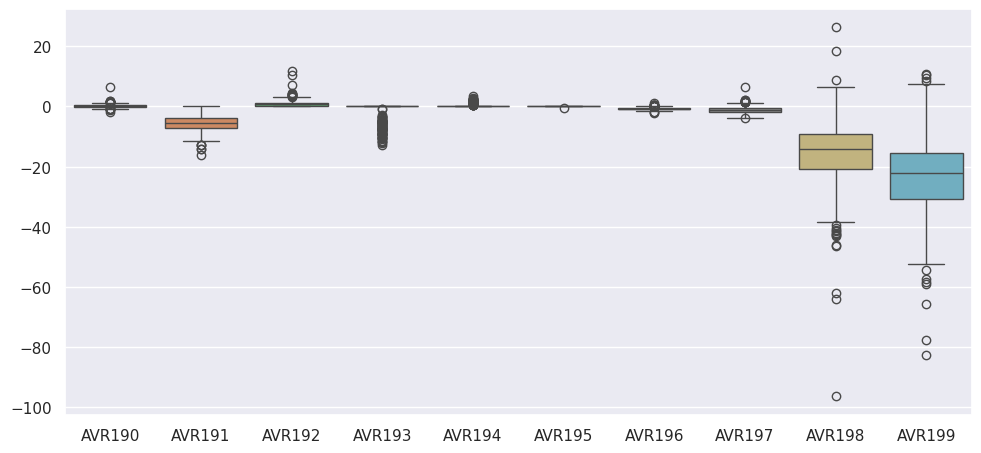

In [250]:
sns.set(rc={'figure.figsize':(11.7,5.27)})
sns.boxplot(data=final_df[["AVR190","AVR191","AVR192","AVR193","AVR194","AVR195","AVR196","AVR197","AVR198","AVR199"]]);

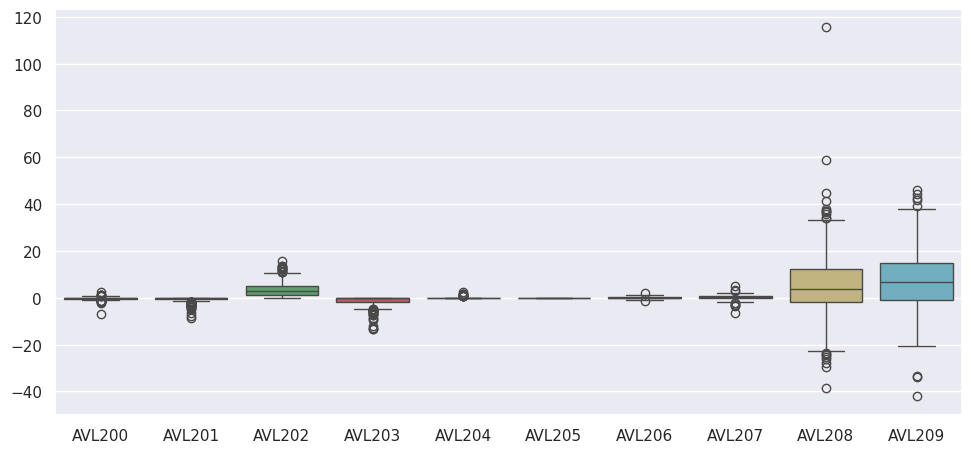

In [251]:
sns.set(rc={'figure.figsize':(11.7,5.27)})
sns.boxplot(data=final_df[["AVL200","AVL201","AVL202","AVL203","AVL204","AVL205","AVL206","AVL207","AVL208","AVL209"]]);

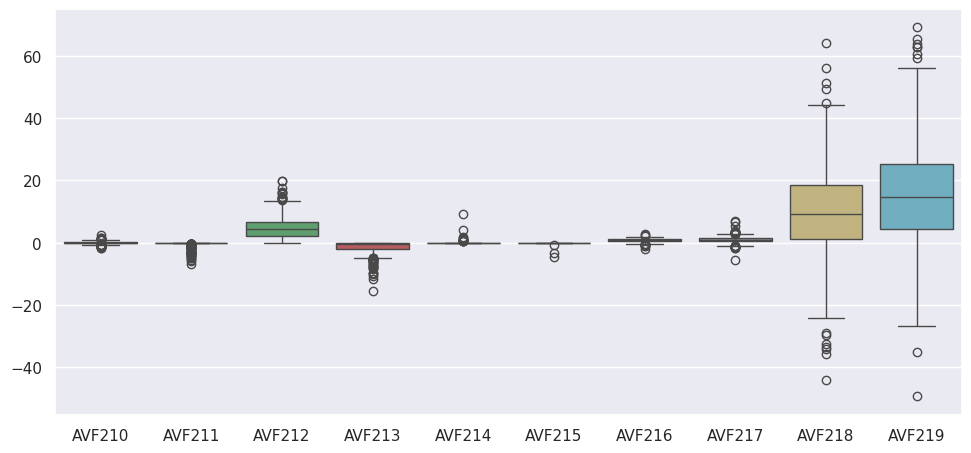

In [252]:
sns.set(rc={'figure.figsize':(11.7,5.27)})
sns.boxplot(data=final_df[["AVF210","AVF211","AVF212","AVF213","AVF214","AVF215","AVF216","AVF217","AVF218","AVF219"]]);

In [253]:
target=new_df["class"]
pearsoncorr = final_df.corrwith(other = target,method='pearson')
pearsoncorr.values

array([-9.63953176e-02, -1.76192726e-01, -4.00467159e-02, -9.17727611e-02,
        3.23918775e-01, -1.01886734e-01,  2.80967349e-02,  9.74853414e-02,
       -1.24816358e-01,  2.19071159e-02,  1.09973839e-04,  1.91310194e-01,
       -3.07437189e-02,  3.34975965e-02,  5.06916325e-03,  4.26729753e-02,
        1.93323243e-01,  6.42496273e-02,             nan,  4.24003165e-02,
       -2.00368330e-02,  7.90239377e-03, -3.53848077e-02,  3.22668039e-02,
        3.22668039e-02,  8.33337655e-02, -2.57462471e-03,  4.96802756e-02,
        1.83319405e-01, -4.09620130e-02,  6.67239854e-02,  6.86287753e-02,
        4.20776827e-02,  8.02811682e-02, -2.00368330e-02,  1.71081283e-02,
       -3.59472363e-02, -4.06504070e-04, -2.71876432e-02,  1.16808189e-01,
        8.34787880e-02,  1.49651215e-02, -3.18332296e-02,  8.03801729e-02,
       -3.07437189e-02,  5.18840837e-02, -3.07437189e-02, -8.38254438e-02,
       -1.13363624e-02, -5.62988506e-03,  2.05040713e-02,  1.75964215e-01,
        3.43370158e-03,  

**Feature Scaling and Splitting dataset**

In [254]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(final_df, target ,test_size=0.2, random_state=1)

In [255]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

scaler.fit(X_train)
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

In [256]:
import warnings
warnings.filterwarnings('ignore')

**Evaluation strategy**

In [257]:
from sklearn.metrics import r2_score,mean_squared_error,accuracy_score,recall_score,precision_score,confusion_matrix,classification_report, confusion_matrix, ConfusionMatrixDisplay

# **3. Modeling**

In [258]:
result = pd.DataFrame(columns=['Model','Train Accuracy','Test Accuracy'])

**KNN Classifier**

In [259]:
from sklearn.neighbors import KNeighborsClassifier
knnclassifier = KNeighborsClassifier()
knnclassifier.fit(X_train, y_train)
y_pred = knnclassifier.predict(X_test)

In [260]:
knn_train_accuracy = accuracy_score(y_train, knnclassifier.predict(X_train))
knn_test_accuracy = accuracy_score(y_test, knnclassifier.predict(X_test))
knn_train_recall = recall_score(y_train, knnclassifier.predict(X_train),average="weighted")
knn_test_recall = recall_score(y_test, knnclassifier.predict(X_test),average="weighted")

In [261]:
print('Train Recall score: {}'
      .format(knn_train_recall))
print('Test Recall score: {}'
      .format(knn_test_recall))
confusion_matrix(y_test, y_pred)

Train Recall score: 0.6611111111111111
Test Recall score: 0.5274725274725275


array([[44,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0],
       [11,  1,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 3,  0,  1,  0,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 2,  0,  0,  1,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 1,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 4,  0,  0,  1,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 1,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 0,  1,  0,  0,  0,  1,  0,  0,  0,  0,  0,  0],
       [ 9,  0,  0,  0,  0,  1,  0,  0,  1,  0,  0,  0],
       [ 2,  1,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 1,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 3,  0,  0,  0,  0,  0,  0,  0,  0,  0,  1,  0]])

In [262]:
result.loc[len(result)] = ['KNN Classifier', knn_train_accuracy, knn_test_accuracy]
result

,Model,Train Accuracy,Test Accuracy
0,KNN Classifier,0.661111,0.527473


**Logistic regression**

In [263]:
from sklearn.linear_model import LogisticRegression
lgclassifier = LogisticRegression(solver = 'saga',random_state = 0)
lgclassifier.fit(X_train, y_train)
y_pred = lgclassifier.predict(X_test)

In [264]:
lg_train_recall = recall_score(y_train, lgclassifier.predict(X_train),average='weighted')
lg_test_recall = recall_score(y_test, lgclassifier.predict(X_test),average='weighted')
lg_train_accuracy = accuracy_score(y_train, lgclassifier.predict(X_train))
lg_test_accuracy = accuracy_score(y_test, lgclassifier.predict(X_test))

In [265]:
print('Train Recall score: {}'
      .format(lg_train_recall))
print('Test Recall score: {}'
      .format(lg_test_recall))
confusion_matrix(y_test, y_pred)

Train Recall score: 0.9472222222222222
Test Recall score: 0.6373626373626373


array([[34,  0,  0,  2,  0,  4,  0,  0,  0,  1,  0,  0,  3],
       [ 3,  5,  0,  0,  0,  1,  0,  0,  0,  1,  0,  2,  0],
       [ 0,  0,  4,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 0,  0,  0,  2,  1,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 1,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 2,  0,  0,  1,  0,  0,  0,  0,  0,  1,  0,  0,  1],
       [ 0,  0,  1,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 0,  0,  0,  0,  0,  0,  0,  1,  1,  0,  0,  0,  0],
       [ 0,  0,  0,  0,  0,  1,  0,  0,  0, 10,  0,  0,  0],
       [ 0,  1,  0,  0,  0,  0,  0,  0,  0,  0,  1,  0,  1],
       [ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  1,  0],
       [ 3,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  1,  0]])

In [266]:
result.loc[len(result)] = ['Logestic Regression', lg_train_accuracy, lg_test_accuracy]
result

,Model,Train Accuracy,Test Accuracy
0,KNN Classifier,0.661111,0.527473
1,Logestic Regression,0.947222,0.637363


**Decision Tree Classifier**

In [267]:
from sklearn.tree import DecisionTreeClassifier
dtclassifier = DecisionTreeClassifier(criterion = 'entropy', random_state = 0,max_depth=5)
dtclassifier.fit(X_train, y_train)
y_pred_test = dtclassifier.predict(X_test)
y_pred_train = dtclassifier.predict(X_train)

In [268]:
dt_train_recall = recall_score(y_train,y_pred_train,average="weighted" )
dt_test_recall = recall_score(y_test, y_pred_test,average="weighted")
dt_train_accuracy = accuracy_score(y_train,y_pred_train )
dt_test_accuracy = accuracy_score(y_test, y_pred_test)

In [269]:
print('Train Recall score: {}'
      .format(dt_train_recall))
print('Test Recall score: {}'
      .format(dt_test_recall))
confusion_matrix(y_test, y_pred_test)

Train Recall score: 0.7833333333333333
Test Recall score: 0.5824175824175825


array([[42,  0,  0,  1,  0,  0,  0,  0,  1,  0,  0,  0],
       [ 6,  4,  0,  2,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 1,  2,  1,  0,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 2,  0,  0,  1,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 1,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 5,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 1,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 1,  0,  0,  0,  0,  0,  0,  1,  0,  0,  0,  0],
       [ 5,  0,  1,  1,  0,  0,  0,  0,  4,  0,  0,  0],
       [ 2,  0,  1,  0,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 1,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 4,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0]])

In [270]:
result.loc[len(result)] = {'Model':'Decision Tree Classifier','Train Accuracy':dt_train_accuracy,'Test Accuracy':dt_test_accuracy}
result

,Model,Train Accuracy,Test Accuracy
0,KNN Classifier,0.661111,0.527473
1,Logestic Regression,0.947222,0.637363
2,Decision Tree Classifier,0.783333,0.582418


**Linear SVM**

In [271]:
from sklearn.svm import LinearSVC
lsvclassifier = LinearSVC(C=0.01)
lsvclassifier.fit(X_train, y_train)
y_pred_test = lsvclassifier.predict(X_test)
y_pred_train = lsvclassifier.predict(X_train)

In [272]:
lsvc_train_accuracy = accuracy_score(y_train, y_pred_train)
lsvc_test_accuracy = accuracy_score(y_test, y_pred_test)
lsvc_train_recall = recall_score(y_train,y_pred_train,average="weighted" )
lsvc_test_recall = recall_score(y_test, y_pred_test,average="weighted")

In [273]:
print('Train Recall score: {}'
      .format(lsvc_train_recall))
print('Test Recall score: {}'
      .format(lsvc_test_recall))
confusion_matrix(y_test, y_pred_test)

Train Recall score: 0.9
Test Recall score: 0.7252747252747253


array([[41,  0,  0,  0,  0,  0,  0,  0,  1,  0,  0,  2],
       [ 4,  5,  1,  0,  0,  1,  0,  0,  1,  0,  0,  0],
       [ 0,  0,  4,  0,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 0,  0,  0,  2,  1,  0,  0,  0,  0,  0,  0,  0],
       [ 1,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 3,  0,  0,  1,  0,  0,  0,  0,  0,  0,  0,  1],
       [ 0,  0,  1,  0,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 1,  0,  0,  0,  0,  0,  0,  1,  0,  0,  0,  0],
       [ 0,  0,  0,  0,  0,  0,  0,  0, 11,  0,  0,  0],
       [ 0,  1,  0,  0,  0,  0,  0,  0,  0,  1,  0,  1],
       [ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  1,  0],
       [ 3,  0,  0,  0,  0,  0,  0,  0,  0,  0,  1,  0]])

In [274]:
result.loc[len(result)] = {'Model':'Linear SVC','Train Accuracy':lsvc_train_accuracy,'Test Accuracy':lsvc_test_accuracy}
result

,Model,Train Accuracy,Test Accuracy
0,KNN Classifier,0.661111,0.527473
1,Logestic Regression,0.947222,0.637363
2,Decision Tree Classifier,0.783333,0.582418
3,Linear SVC,0.900000,0.725275


**Kernelized SVM**

In [275]:
from sklearn import svm
KSVC_clf = svm.SVC(kernel='sigmoid',C=10,gamma=0.001)
KSVC_clf.fit(X_train, y_train)
y_pred_train = KSVC_clf.predict(X_train)
y_pred_test = KSVC_clf.predict(X_test)

In [276]:
ksvc_train_recall = recall_score(y_train,y_pred_train,average="weighted" )
ksvc_test_recall = recall_score(y_test, y_pred_test,average="weighted")

ksvc_train_accuracy = accuracy_score(y_train, y_pred_train)
ksvc_test_accuracy = accuracy_score(y_test, y_pred_test)

In [277]:
print('Train Recall score: {}'
      .format(ksvc_train_recall))
print('Test Recall score: {}'
      .format(ksvc_test_recall))
confusion_matrix(y_test, y_pred_test)

Train Recall score: 0.8777777777777778
Test Recall score: 0.6703296703296703


array([[43,  0,  0,  0,  0,  0,  0,  0,  1,  0,  0,  0],
       [ 5,  5,  0,  0,  0,  0,  0,  0,  0,  0,  2,  0],
       [ 0,  0,  4,  0,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 2,  0,  0,  1,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 1,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 4,  0,  0,  1,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 0,  0,  1,  0,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 1,  0,  0,  0,  0,  0,  0,  1,  0,  0,  0,  0],
       [ 4,  1,  0,  0,  0,  0,  0,  0,  6,  0,  0,  0],
       [ 2,  1,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  1,  0],
       [ 3,  0,  0,  0,  0,  0,  0,  0,  0,  0,  1,  0]])

In [278]:
result.loc[len(result)] = {'Model':'Kernelized SVC','Train Accuracy':ksvc_train_accuracy,'Test Accuracy':ksvc_test_accuracy}
result

,Model,Train Accuracy,Test Accuracy
0,KNN Classifier,0.661111,0.527473
1,Logestic Regression,0.947222,0.637363
2,Decision Tree Classifier,0.783333,0.582418
3,Linear SVC,0.900000,0.725275
4,Kernelized SVC,0.877778,0.670330


**Random Forest Classifier**

In [279]:
from sklearn.ensemble import RandomForestClassifier
rf_clf = RandomForestClassifier(n_estimators=300, criterion='gini',max_features=100,max_depth=10,max_leaf_nodes=30)
rf_clf.fit(X_train, y_train)

RandomForestClassifier(max_depth=10, max_features=100, max_leaf_nodes=30,
                       n_estimators=300)

In [280]:
y_pred_train = rf_clf.predict(X_train)
y_pred_test = rf_clf.predict(X_test)

rf_train_accuracy = accuracy_score(y_train, y_pred_train)
rf_test_accuracy = accuracy_score(y_test, y_pred_test)
rf_train_recall = recall_score(y_train,y_pred_train,average="weighted" )
rf_test_recall = recall_score(y_test, y_pred_test,average="weighted")

In [281]:
print('Train Recall score: {}'
      .format(rf_train_recall))
print('Test Recall score: {}'
      .format(rf_test_recall))
confusion_matrix(y_test, y_pred_test)

Train Recall score: 0.9166666666666666
Test Recall score: 0.6813186813186813


array([[42,  0,  0,  1,  0,  0,  0,  0,  1,  0,  0,  0],
       [ 6,  5,  0,  1,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 0,  0,  4,  0,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 2,  0,  0,  1,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 1,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 4,  0,  0,  1,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 0,  0,  1,  0,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 1,  0,  0,  0,  0,  0,  0,  1,  0,  0,  0,  0],
       [ 1,  1,  0,  0,  0,  0,  0,  0,  9,  0,  0,  0],
       [ 2,  1,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 1,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 4,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0]])

In [282]:
result.loc[len(result)] = {'Model':'Random Forest Classifier','Train Accuracy':rf_train_accuracy,'Test Accuracy':rf_test_accuracy}
result

,Model,Train Accuracy,Test Accuracy
0,KNN Classifier,0.661111,0.527473
1,Logestic Regression,0.947222,0.637363
2,Decision Tree Classifier,0.783333,0.582418
3,Linear SVC,0.900000,0.725275
4,Kernelized SVC,0.877778,0.670330
5,Random Forest Classifier,0.916667,0.681319


**PCA**

In [283]:
from sklearn.decomposition import PCA
pca = PCA(.98)
pca.fit(X_train)
pca.n_components_

np.int64(121)

In [284]:
X_train_pca = pca.transform(X_train)
X_test_pca = pca.transform(X_test)

In [285]:
from sklearn.model_selection import StratifiedKFold
kFold = StratifiedKFold(n_splits=5)
from sklearn.model_selection import GridSearchCV

**KNN with PCA**

In [286]:
from sklearn.neighbors import KNeighborsClassifier
knnp_clf = KNeighborsClassifier(n_neighbors=5)
knnp_clf.fit(X_train_pca, y_train)
y_pred_train = knnp_clf.predict(X_train_pca)
y_pred_test = knnp_clf.predict(X_test_pca)

In [287]:
knnp_train_recall = recall_score(y_train, y_pred_train, average='weighted')
knnp_test_recall = recall_score(y_test, y_pred_test, average='weighted')
knnp_train_accuracy = accuracy_score(y_train, y_pred_train)
knnp_test_accuracy = accuracy_score(y_test, y_pred_test)

In [288]:
print('Train Recall score: {}'
      .format(knnp_train_recall))
print('Test Recall score: {}'
      .format(knnp_test_recall))

confusion_matrix(y_test, y_pred_test)

Train Recall score: 0.6694444444444444
Test Recall score: 0.5164835164835165


array([[44,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0],
       [11,  1,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 3,  0,  1,  0,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 2,  0,  0,  1,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 1,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 5,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 1,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 0,  1,  0,  0,  0,  1,  0,  0,  0,  0,  0,  0],
       [10,  0,  0,  1,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 2,  1,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 1,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 3,  0,  0,  0,  0,  0,  0,  0,  0,  0,  1,  0]])

In [289]:
result.loc[len(result)] = {'Model':'KNN Classifier with PCA','Train Accuracy':knnp_train_accuracy,'Test Accuracy':knnp_test_accuracy}
result

,Model,Train Accuracy,Test Accuracy
0,KNN Classifier,0.661111,0.527473
1,Logestic Regression,0.947222,0.637363
2,Decision Tree Classifier,0.783333,0.582418
3,Linear SVC,0.900000,0.725275
4,Kernelized SVC,0.877778,0.670330
5,Random Forest Classifier,0.916667,0.681319
6,KNN Classifier with PCA,0.669444,0.516484


**Logestic with PCA**

In [290]:
from sklearn.linear_model import LogisticRegression
lgp_clf = LogisticRegression(solver='saga',C=0.01)
lgp_clf.fit(X_train_pca, y_train)
y_pred_train = lgp_clf.predict(X_train_pca)
y_pred_test = lgp_clf.predict(X_test_pca)

In [291]:
lgp_train_recall = recall_score(y_train, y_pred_train, average='weighted')
lgp_test_recall = recall_score(y_test, y_pred_test, average='weighted')
lgp_train_accuracy = accuracy_score(y_train, y_pred_train)
lgp_test_accuracy = accuracy_score(y_test, y_pred_test)

In [292]:
print('Train Recall score: {}'
      .format(lgp_train_recall))
print('Test Recall score: {}'
      .format(lgp_test_recall))

confusion_matrix(y_test, y_pred_test)

Train Recall score: 0.8083333333333333
Test Recall score: 0.6593406593406593


array([[43,  0,  0,  0,  0,  0,  0,  0,  1,  0,  0,  0],
       [ 6,  5,  0,  0,  0,  0,  0,  0,  0,  0,  0,  1],
       [ 0,  0,  4,  0,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 2,  0,  0,  1,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 1,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 4,  0,  0,  1,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 0,  0,  1,  0,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 1,  0,  0,  0,  0,  0,  0,  1,  0,  0,  0,  0],
       [ 6,  0,  0,  0,  0,  0,  0,  0,  5,  0,  0,  0],
       [ 2,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  1],
       [ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  1,  0],
       [ 3,  1,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0]])

In [293]:
result.loc[len(result)] = {'Model':'Logestic Regression with PCA','Train Accuracy':lgp_train_accuracy,'Test Accuracy':lgp_test_accuracy}
result

,Model,Train Accuracy,Test Accuracy
0,KNN Classifier,0.661111,0.527473
1,Logestic Regression,0.947222,0.637363
2,Decision Tree Classifier,0.783333,0.582418
3,Linear SVC,0.900000,0.725275
4,Kernelized SVC,0.877778,0.670330
5,Random Forest Classifier,0.916667,0.681319
6,KNN Classifier with PCA,0.669444,0.516484
7,Logestic Regression with PCA,0.808333,0.659341


**Linear svm with PCA**

In [294]:
from sklearn.svm import LinearSVC
LSVC_clf = LinearSVC(C=0.001)
LSVC_clf.fit(X_train_pca, y_train)
y_pred_train = LSVC_clf.predict(X_train_pca)
y_pred_test = LSVC_clf.predict(X_test_pca)

In [295]:
lsvcp_train_recall = recall_score(y_train, y_pred_train, average='weighted')
lsvcp_test_recall = recall_score(y_test, y_pred_test, average='weighted')
lsvcp_train_accuracy = accuracy_score(y_train, y_pred_train)
lsvcp_test_accuracy = accuracy_score(y_test, y_pred_test)

In [296]:
print('Train Recall score: {}'
      .format(lsvcp_train_recall))
print('Test Recall score: {}'
      .format(lsvcp_test_recall))

confusion_matrix(y_test, y_pred_test)

Train Recall score: 0.825
Test Recall score: 0.6813186813186813


array([[38,  1,  0,  2,  0,  0,  0,  0,  2,  0,  0,  1],
       [ 4,  5,  0,  0,  1,  0,  0,  0,  1,  0,  1,  0],
       [ 0,  0,  4,  0,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 0,  1,  0,  1,  0,  0,  0,  0,  1,  0,  0,  0],
       [ 1,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 4,  0,  0,  1,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 0,  0,  1,  0,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 0,  0,  0,  0,  0,  0,  0,  2,  0,  0,  0,  0],
       [ 1,  0,  0,  0,  0,  0,  0,  0, 10,  0,  0,  0],
       [ 0,  1,  0,  0,  0,  0,  0,  0,  0,  1,  0,  1],
       [ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  1,  0],
       [ 3,  0,  0,  0,  0,  0,  0,  0,  0,  0,  1,  0]])

In [297]:
result.loc[len(result)] = {'Model':'Linear SVC with PCA','Train Accuracy':lsvcp_train_accuracy,'Test Accuracy':lsvcp_test_accuracy}
result

,Model,Train Accuracy,Test Accuracy
0,KNN Classifier,0.661111,0.527473
1,Logestic Regression,0.947222,0.637363
2,Decision Tree Classifier,0.783333,0.582418
3,Linear SVC,0.900000,0.725275
4,Kernelized SVC,0.877778,0.670330
5,Random Forest Classifier,0.916667,0.681319
6,KNN Classifier with PCA,0.669444,0.516484
7,Logestic Regression with PCA,0.808333,0.659341
8,Linear SVC with PCA,0.825000,0.681319


**Kernal svm with PCA**

In [298]:
from sklearn import svm
KSVC_clf = svm.SVC(kernel='sigmoid',C=10,gamma=0.001)

KSVC_clf.fit(X_train_pca, y_train)
y_pred_train = KSVC_clf.predict(X_train_pca)
y_pred_test = KSVC_clf.predict(X_test_pca)

In [299]:
ksvcp_train_recall = recall_score(y_train, y_pred_train, average='weighted')
ksvcp_test_recall = recall_score(y_test, y_pred_test, average='weighted')
ksvcp_train_accuracy = accuracy_score(y_train, y_pred_train,)
ksvcp_test_accuracy = accuracy_score(y_test, y_pred_test)

In [300]:
print('Train Recall score: {}'
      .format(ksvcp_train_recall))
print('Test Recall score: {}'
      .format(ksvcp_test_recall))

confusion_matrix(y_test, y_pred_test)

Train Recall score: 0.8555555555555555
Test Recall score: 0.6703296703296703


array([[43,  0,  0,  0,  0,  0,  0,  0,  1,  0,  0,  0],
       [ 5,  5,  0,  0,  0,  0,  0,  0,  0,  0,  2,  0],
       [ 0,  0,  4,  0,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 2,  0,  0,  1,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 1,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 4,  0,  0,  1,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 0,  0,  1,  0,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 1,  0,  0,  0,  0,  0,  0,  1,  0,  0,  0,  0],
       [ 4,  1,  0,  0,  0,  0,  0,  0,  6,  0,  0,  0],
       [ 2,  1,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  1,  0],
       [ 3,  0,  0,  0,  0,  0,  0,  0,  0,  0,  1,  0]])

In [301]:
result.loc[len(result)] = {'Model':'kernelized SVC with PCA','Train Accuracy':ksvcp_train_accuracy,'Test Accuracy':ksvcp_test_accuracy}
result

,Model,Train Accuracy,Test Accuracy
0,KNN Classifier,0.661111,0.527473
1,Logestic Regression,0.947222,0.637363
2,Decision Tree Classifier,0.783333,0.582418
3,Linear SVC,0.900000,0.725275
4,Kernelized SVC,0.877778,0.670330
5,Random Forest Classifier,0.916667,0.681319
6,KNN Classifier with PCA,0.669444,0.516484
7,Logestic Regression with PCA,0.808333,0.659341
8,Linear SVC with PCA,0.825000,0.681319
9,kernelized SVC with PCA,0.855556,0.670330


**DecisionTree Classifier with PCA**

In [302]:
from sklearn.tree import DecisionTreeClassifier
dt_clf = DecisionTreeClassifier(criterion = 'entropy', random_state = 2,max_depth=5)
dt_clf.fit(X_train_pca, y_train)
y_pred_train = dt_clf.predict(X_train_pca)
y_pred_test = dt_clf.predict(X_test_pca)

In [303]:
dtp_train_recall = recall_score(y_train, y_pred_train, average='weighted')
dtp_test_recall = recall_score(y_test, y_pred_test, average='weighted')
dtp_train_accuracy = accuracy_score(y_train, y_pred_train)
dtp_test_accuracy = accuracy_score(y_test, y_pred_test)

In [304]:
print('Train Recall score: {}'
      .format(dtp_train_recall))
print('Test Recall score: {}'
      .format(dtp_test_recall))

confusion_matrix(y_test, y_pred_test)

Train Recall score: 0.7694444444444445
Test Recall score: 0.4835164835164835


array([[33,  4,  1,  0,  1,  0,  0,  0,  5,  0,  0,  0],
       [ 7,  3,  0,  1,  0,  0,  0,  0,  0,  0,  1,  0],
       [ 2,  0,  2,  0,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 1,  1,  0,  1,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 1,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 4,  1,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 0,  1,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 0,  0,  1,  0,  0,  0,  0,  1,  0,  0,  0,  0],
       [ 6,  0,  1,  0,  1,  0,  0,  0,  3,  0,  0,  0],
       [ 2,  0,  0,  1,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  1,  0],
       [ 3,  0,  0,  0,  0,  0,  0,  0,  0,  0,  1,  0]])

In [305]:
result.loc[len(result)] = {'Model':'DecisionTree Classifier with PCA','Train Accuracy':dtp_train_accuracy,'Test Accuracy':dtp_test_accuracy}
result

,Model,Train Accuracy,Test Accuracy
0,KNN Classifier,0.661111,0.527473
1,Logestic Regression,0.947222,0.637363
2,Decision Tree Classifier,0.783333,0.582418
3,Linear SVC,0.900000,0.725275
4,Kernelized SVC,0.877778,0.670330
5,Random Forest Classifier,0.916667,0.681319
6,KNN Classifier with PCA,0.669444,0.516484
7,Logestic Regression with PCA,0.808333,0.659341
8,Linear SVC with PCA,0.825000,0.681319
9,kernelized SVC with PCA,0.855556,0.670330


**Random Forest Classifier With PCA**

In [306]:
from sklearn.ensemble import RandomForestClassifier
rfp_clf = RandomForestClassifier()
rfp_clf.fit(X_train_pca, y_train)
y_pred_train = rfp_clf.predict(X_train_pca)
y_pred_test = rfp_clf.predict(X_test_pca)

In [307]:
rfp_train_recall = recall_score(y_train, y_pred_train, average='weighted')
rfp_test_recall = recall_score(y_test, y_pred_test, average='weighted')
rfp_train_accuracy = accuracy_score(y_train, y_pred_train)
rfp_test_accuracy = accuracy_score(y_test, y_pred_test)

In [308]:
print('Train Recall score: {}'
      .format(rfp_train_recall))
print('Test Recall score: {}'
      .format(rfp_test_recall))

confusion_matrix(y_test, y_pred_test)

Train Recall score: 1.0
Test Recall score: 0.5824175824175825


array([[44,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 9,  2,  0,  0,  0,  1,  0,  0,  0,  0,  0,  0],
       [ 3,  0,  1,  0,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 3,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 1,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 5,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 1,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 1,  0,  0,  0,  0,  0,  0,  1,  0,  0,  0,  0],
       [ 5,  1,  0,  0,  0,  0,  0,  0,  5,  0,  0,  0],
       [ 2,  0,  0,  0,  0,  0,  0,  0,  1,  0,  0,  0],
       [ 1,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 4,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0]])

In [309]:
result.loc[len(result)] = {'Model':'Random Forest Classifier with PCA','Train Accuracy':rfp_train_accuracy,'Test Accuracy':rfp_test_accuracy}
result

,Model,Train Accuracy,Test Accuracy
0,KNN Classifier,0.661111,0.527473
1,Logestic Regression,0.947222,0.637363
2,Decision Tree Classifier,0.783333,0.582418
3,Linear SVC,0.900000,0.725275
4,Kernelized SVC,0.877778,0.670330
5,Random Forest Classifier,0.916667,0.681319
6,KNN Classifier with PCA,0.669444,0.516484
7,Logestic Regression with PCA,0.808333,0.659341
8,Linear SVC with PCA,0.825000,0.681319
9,kernelized SVC with PCA,0.855556,0.670330


# **Result**

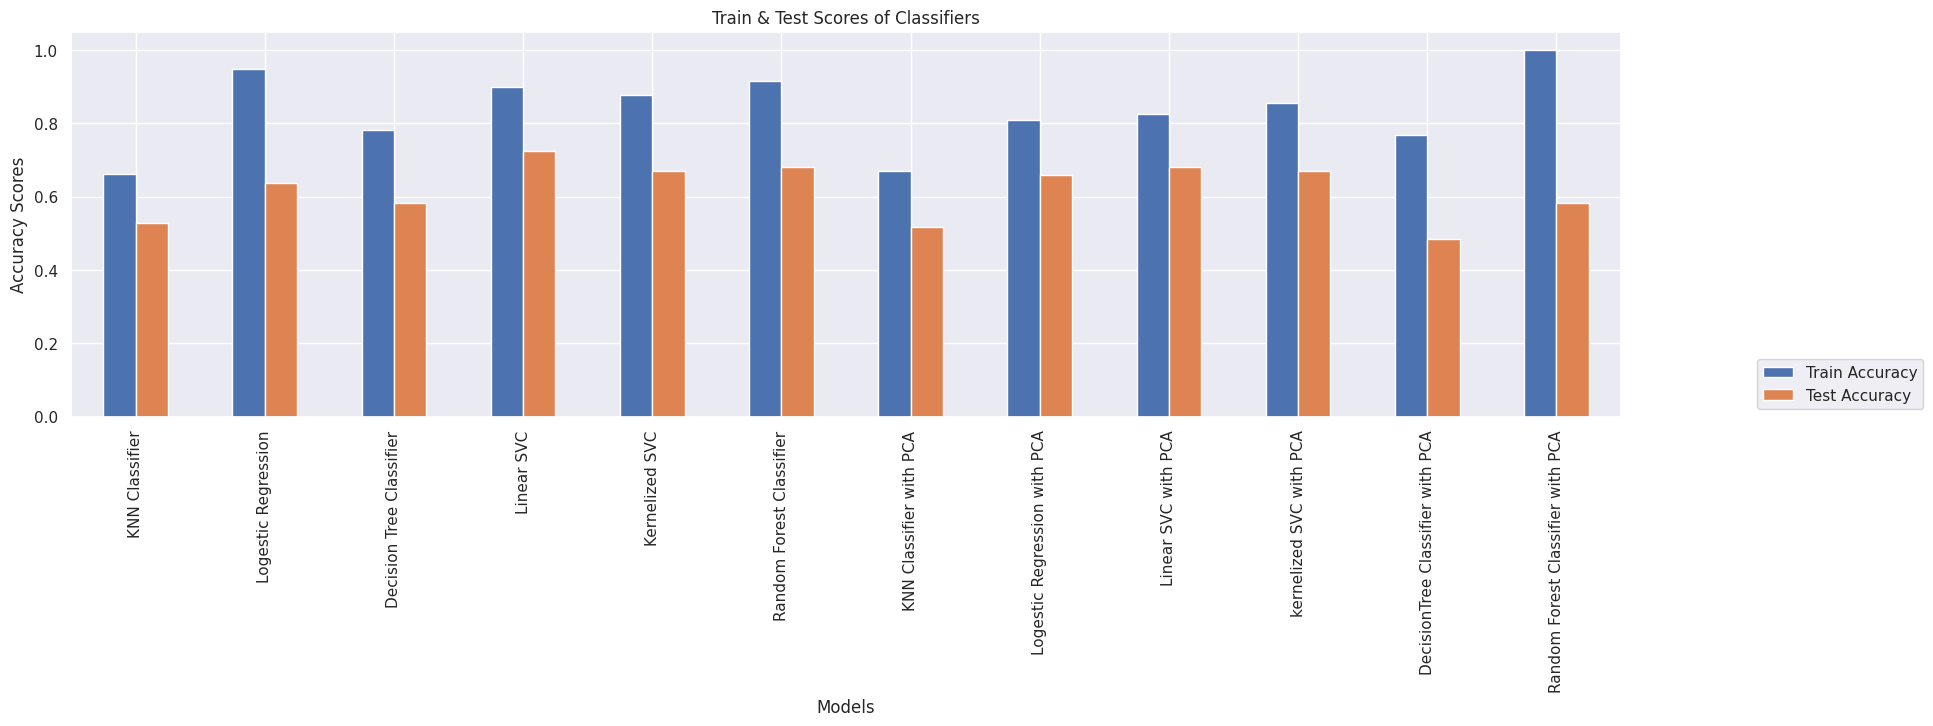

In [310]:
ax=result.plot(kind="bar",figsize=(20,5))
ax.set_xticks(result.index)
ax.set_xticklabels(result.Model,rotation=90)
plt.title('Train & Test Scores of Classifiers')
plt.xlabel('Models')
plt.ylabel('Accuracy Scores')
plt.legend(loc=4 , bbox_to_anchor=(1.2, 0))
plt.show();

# **Conclusion**

The models started performing better after we applied PCA on the resampled data. The reason behind this is, PCA reduces the complexity of the data. It creates components based on giving importance to variables with large variance and also the components which it creates are non collinear in nature which means it takes care of collinearity in large data set. PCA also improves the overall execution time and quality of the models and it is very beneficial when we are working with huge amount of variables.

The Best model in term of recall score is Kernalized SVM with PCA having accuracy of 80.21%.